# Classification Trees — LOOCV revision

**Purpose.** Replace the single hold-out split of
[`03_classification_trees.ipynb`](03_classification_trees.ipynb) with full
leave-one-out cross-validation for both bioindicator taxa, so the tree models are
evaluated on the same footing (LOOCV, n = 18) as the logistic and fuzzy models.
**Created/modified:** 2026-06-23.
**Supports article section:** Methods (validation) and Results (Table 9).

## Methodological notes

- **Same predictors and depth as the original notebook:** the seven physicochemical
  predictors `COT, DBO5, Dureza, Magnesio, Turbiedad, OD, Caudal` and `max_depth=3`.
- **`class_weight='balanced'`** is added to match the logistic-regression treatment of
  class imbalance (Perlidae 6/18 present; Helicopsychidae 3/18 present). The original
  trees notebook did not balance classes; this change makes the trees comparable to
  the other techniques and prevents trivial majority-class prediction.
- **Validation = LOOCV**, replacing the original 70/30 hold-out (whose 6-observation
  test set gave high-variance estimates). Calibration (training) metrics are also
  reported for context.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import (classification_report, confusion_matrix, cohen_kappa_score,
                             accuracy_score, precision_recall_fscore_support)
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

df = pd.read_excel("../../data/DB - Macroinvertebrados.xlsx")
df.columns = df.columns.str.strip()

predictor_cols = ['COT', 'DBO5', 'Dureza', 'Magnesio', 'Turbiedad', 'OD', 'Caudal']
print("Predictors:", predictor_cols)
print("n =", len(df))

Predictors: ['COT', 'DBO5', 'Dureza', 'Magnesio', 'Turbiedad', 'OD', 'Caudal']
n = 18


In [2]:
# LOOCV for both taxa with class_weight='balanced', max_depth=3
loo = LeaveOneOut()
tree_results = {}

for taxon, y_col in [('Perlidae', 'Perlidae'), ('Helicopsychidae', 'Trichoptera')]:
    X = df[predictor_cols]
    y = df[y_col]
    y_true_val, y_pred_val, y_true_cal, y_pred_cal = [], [], [], []
    print(f"{taxon} LOOCV folds:", end=' ')
    for fold, (train_idx, test_idx) in enumerate(loo.split(X)):
        print(f"{fold+1}", end=' ', flush=True)
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        clf = DecisionTreeClassifier(max_depth=3, random_state=42, class_weight='balanced')
        clf.fit(X_train, y_train)
        y_true_val.append(y_test.iloc[0]); y_pred_val.append(clf.predict(X_test)[0])
        y_true_cal.extend(y_train.tolist()); y_pred_cal.extend(clf.predict(X_train).tolist())
    print("done.")
    p, r, f, _ = precision_recall_fscore_support(y_true_val, y_pred_val, labels=[0, 1],
                                                 average='macro', zero_division=0)
    tree_results[taxon] = {
        'y_true_val': y_true_val, 'y_pred_val': y_pred_val,
        'precision': p, 'recall': r, 'f1': f,
        'accuracy': accuracy_score(y_true_val, y_pred_val),
        'kappa': cohen_kappa_score(y_true_val, y_pred_val),
        'cal_accuracy': accuracy_score(y_true_cal, y_pred_cal),
    }
    print(f"  {taxon}: validation accuracy={tree_results[taxon]['accuracy']:.3f} "
          f"kappa={tree_results[taxon]['kappa']:.3f} "
          f"(calibration acc={tree_results[taxon]['cal_accuracy']:.3f})")

Perlidae LOOCV folds: 1 

2 

3 

4 

5 

...

16 

17 

18 

done.

  Helicopsychidae: validation accuracy=0.833 kappa=0.308 (calibration acc=1.000)


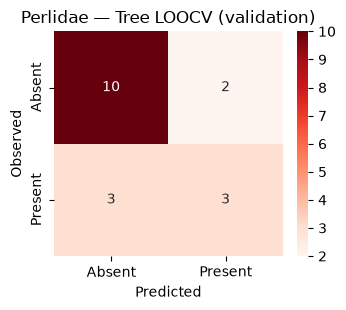

=== Perlidae classification report (validation, LOOCV) ===
              precision    recall  f1-score   support

      Absent       0.77      0.83      0.80        12
     Present       0.60      0.50      0.55         6

    accuracy                           0.72        18
   macro avg       0.68      0.67      0.67        18
weighted avg       0.71      0.72      0.72        18



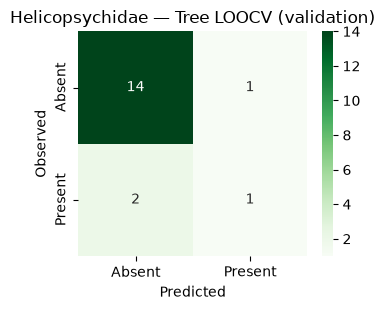

=== Helicopsychidae classification report (validation, LOOCV) ===
              precision    recall  f1-score   support

      Absent       0.88      0.93      0.90        15
     Present       0.50      0.33      0.40         3

    accuracy                           0.83        18
   macro avg       0.69      0.63      0.65        18
weighted avg       0.81      0.83      0.82        18



In [3]:
# Confusion matrices and classification reports (validation, LOOCV)
for taxon, cmap in [('Perlidae', 'Reds'), ('Helicopsychidae', 'Greens')]:
    res = tree_results[taxon]
    cm = confusion_matrix(res['y_true_val'], res['y_pred_val'], labels=[0, 1])
    plt.figure(figsize=(3.6, 3.2))
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, xticklabels=['Absent', 'Present'],
                yticklabels=['Absent', 'Present'])
    plt.title(f"{taxon} — Tree LOOCV (validation)"); plt.xlabel('Predicted'); plt.ylabel('Observed')
    plt.tight_layout(); plt.show()
    print(f"=== {taxon} classification report (validation, LOOCV) ===")
    print(classification_report(res['y_true_val'], res['y_pred_val'], labels=[0, 1],
                                target_names=['Absent', 'Present'], zero_division=0))

### Comparison with the original hold-out result

The original notebook reported a single 70/30 hold-out test accuracy of **0.833 for
both taxa**, but on only **6 test observations** — a high-variance estimate that
cannot separate skill from luck. The LOOCV accuracies above are the honest
generalisation estimates and should replace the hold-out numbers in the article.

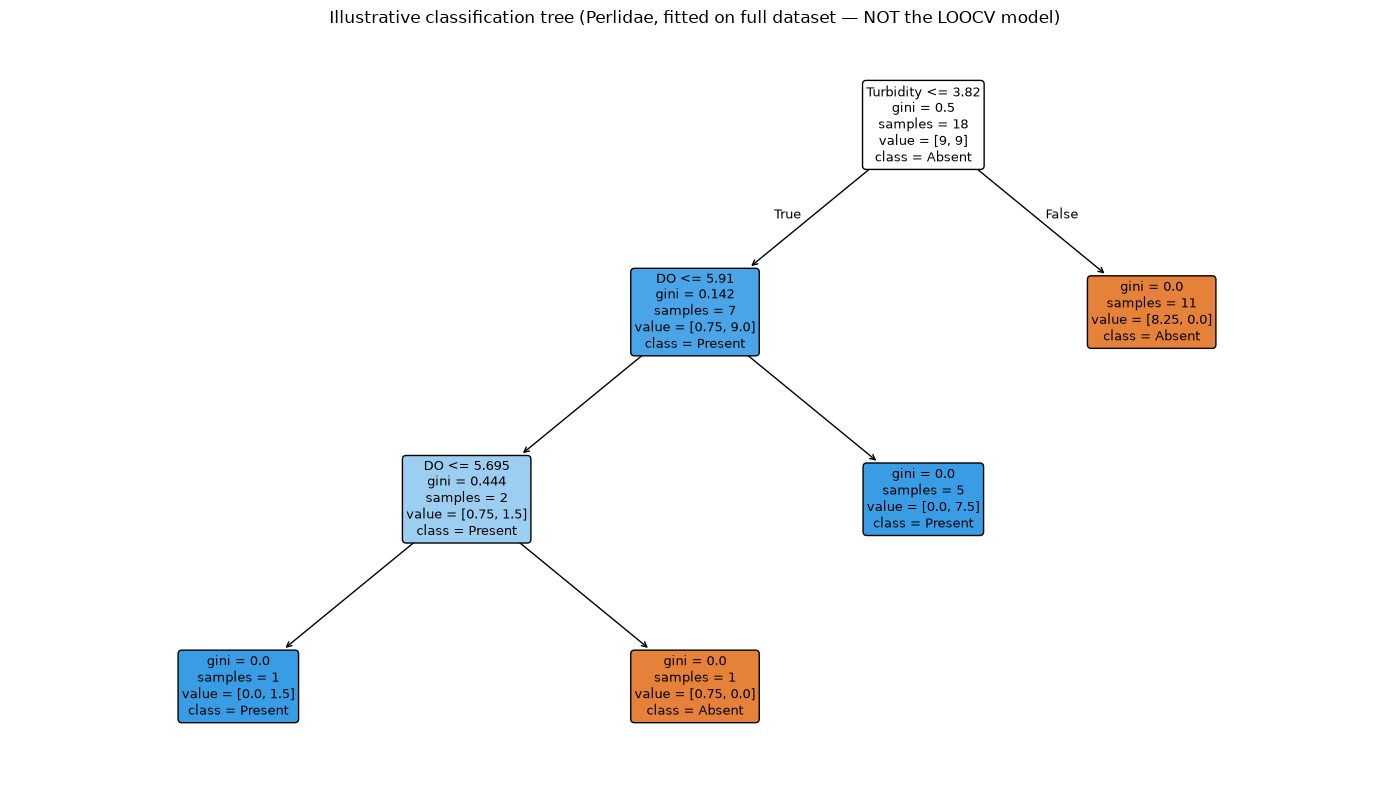

In [4]:
# One representative tree fitted on the FULL dataset — for visualisation only
feature_names_en = ['TOC', 'BOD5', 'Hardness', 'Magnesium', 'Turbidity', 'DO', 'Flowrate']
clf_full = DecisionTreeClassifier(max_depth=3, random_state=42, class_weight='balanced')
clf_full.fit(df[predictor_cols], df['Perlidae'])
plt.figure(figsize=(14, 8))
plot_tree(clf_full, feature_names=feature_names_en, class_names=['Absent', 'Present'],
          filled=True, rounded=True, fontsize=9)
plt.title("Illustrative classification tree (Perlidae, fitted on full dataset — NOT the LOOCV model)")
plt.tight_layout(); plt.show()

In [5]:
# Export tree LOOCV metrics in the shared schema for the master notebook
rows = []
for taxon in ['Perlidae', 'Helicopsychidae']:
    res = tree_results[taxon]
    rows.append({'target': taxon, 'technique': 'Classification trees', 'validation': 'LOOCV',
                 'n': 18, 'precision': round(res['precision'], 3), 'recall': round(res['recall'], 3),
                 'f1': round(res['f1'], 3), 'accuracy': round(res['accuracy'], 3),
                 'kappa': round(res['kappa'], 3)})
pd.DataFrame(rows).to_csv("../../outputs/metrics_trees.csv", index=False)
print("Saved outputs/metrics_trees.csv")
print(pd.DataFrame(rows).to_string(index=False))

Saved outputs/metrics_trees.csv
         target            technique validation  n  precision  recall    f1  accuracy  kappa
       Perlidae Classification trees      LOOCV 18      0.685   0.667 0.673     0.722  0.348
Helicopsychidae Classification trees      LOOCV 18      0.688   0.633 0.652     0.833  0.308
